In [0]:
storage_account_name = "jana60305219"
storage_account_key = "0GM7spdOovemizH7Y7FRNCvl/bLz5y0odTdC9mhp2Lm4/cxI9htWaDjHJU6iBEZlvhmmY8ymw3ic+AStT8nfqQ=="
spark.conf.set(
 f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
 storage_account_key
)

In [0]:
enriched_reviews_path = "abfss://processed@jana60305219.dfs.core.windows.net/enriched_reviews/"
enriched_df = spark.read.parquet(enriched_reviews_path)

In [0]:
features_v1_df = enriched_df.select(
 "asin",
 "title",
 "brand",
 "price",
 "reviewerID",
 "overall",
 "summary",
 "reviewText",
 "helpful",
 "reviewTime",
 "review_year"
)

In [0]:
# Use the EXACT name from your error: jana60305219
spark.conf.set(
    "fs.azure.account.key.jana60305219.dfs.core.windows.net", 
    "0GM7spdOovemizH7Y7FRNCvl/bLz5y0odTdC9mhp2Lm4/cxI9htWaDjHJU6iBEZlvhmmY8ymw3ic+AStT8nfqQ==" # <--- Ensure no spaces before or after the key
)


In [0]:
gold_path = "abfss://curated@jana60305219.dfs.core.windows.net/features_v1/" 
features_v1_df.write.mode("overwrite").parquet(gold_path) 

In [0]:
gold_df = spark.read.parquet(gold_path) 
gold_df.printSchema() 
display(gold_df.limit(5)) 
print("Final row count:", gold_df.count()) 

root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)



asin,title,brand,price,reviewerID,overall,summary,reviewText,helpful,reviewTime,review_year
B000AMLXHW,Sling Media Slingbox Classic,Sling Media,129.93,A3OI6H4WL2M5W5,5.0,Exceeded my expectations.,"Seldom does a gadget exceed my expectations, but the Slingbox did just that. I've been looking for a way to get television into my office. The building offers satellite, but it is very expensive and there is too much interference for rabbit ears. I bought the Slingbox, fully expecting that it would offer at best a grainy, jittery picture. I was amazed at the image I received on my office computer. Like any streaming video, the image degenerates as you enlarge it so I keep it small, but that is all I need for an on the road or in the office television picture. It's not as though my family will be gathering around my computer monitor. Obviously the quality of your picture will depend on the available bandwidth at both ends of the connection, and since your upload speed is usually slower than your download speed, that may prove to be the weak link. I have a cable connection at home with a good upload speed. If you have a DSL connection with a limited upload speed, your results may not be as good as mine.I was also very impressed by the ease of setting up the Slingbox. The process is a little involved since you must create an access port through your home router (so that you can reach the signal remotely), but Slingbox makes it amazingly simple. The installation program lists every popular make and model of router, then provides screen shots that show you how to configure that specific router. Any other product would have simply said, ""contact your router's manufacturer for information,"" but Slingbox has done all the homework for you. When you set up the box, you can hook it up to and control just about any video source. I hooked it up to my cable directly because I don't need access to any premium channels at work, but you can tie it into your cable or satellite box or even your Tivo box. The advantage to using just the cable connection is that the Slingbox then uses it's own tuner, and I do not have to worry about changing the cable box channel remotely, unaware that I am interrupting my wife's viewing of the crucial moment of Survivor.Another use I had not planned on was the ability to have a mobile television at home. Sony offers a remote television that sends out a signal from your video source, enabling you to watch TV in the backyard, bathroom, etc. That unit sells for around $1,000. I now have the same capability on my laptop, and when you use the Slingbox on your own local network, the transfer speeds are so fast that you can watch the program full screen with no degradation of the picture. If I am in the middle of an interesting show but have a sudden craving to smoke a cigar on the veranda, I can just take my laptop and continue watching the show.","List(14, 15)","12 16, 2005",2005
B000AMLXHW,Sling Media Slingbox Classic,Sling Media,129.93,A28HUBMSCXVQW0,5.0,Coolest thing since TiVo,"I finally heard enough ranting and raving from my associates about how cool Slingbox was. Since I travel alot (domestic and International) I thought that watching my TiVo from other parts of the world would be cool. As a matter of fact, it is VERY COOL. I can sit in my hotel room in Shanghai (Broadband) and control my TiVo in Kentucky on my laptop (full screen). It looks great too. I thought that the picture and sound would be degraded if I went to a WiFi connection (10Mps) instead of my 100Mps wired ethernet setup. Even on WiFi, the picture looked great with no degrade detected. On another note, my wife is complaining because she thought she had complete TV control with me on the other side of the planet, not any more :) The instructions for hooking up the Slingbox were very easy to follow, the more challenging part was enabling my router for port forwarding so that I could remotely control my TiVo from anywhere on the Internet. The installatio

Final row count: 1687427


/home/spark-064d4186-d93f-4a9c-82be-eb/.ipykernel/2050/command-7959118198904835-27058496:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pdf_rating, x='overall', palette='viridis')


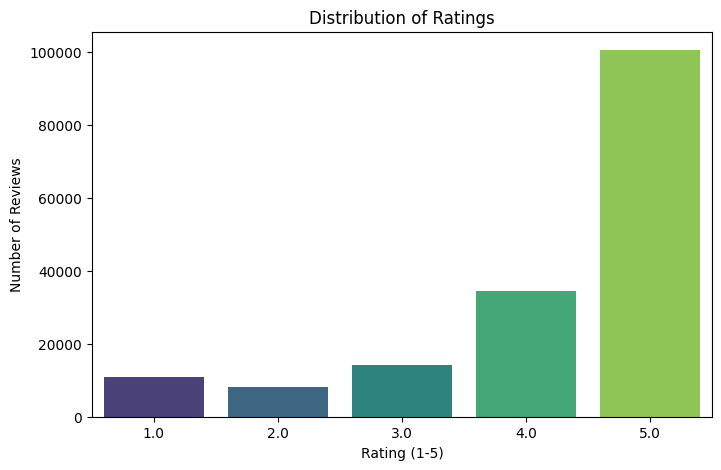

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sample 10% of the data to avoid crashing the driver memory
pdf_rating = gold_df.select("overall").sample(False, 0.1, seed=42).toPandas()

plt.figure(figsize=(8, 5))
sns.countplot(data=pdf_rating, x='overall', palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating (1-5)')
plt.ylabel('Number of Reviews')
plt.show()

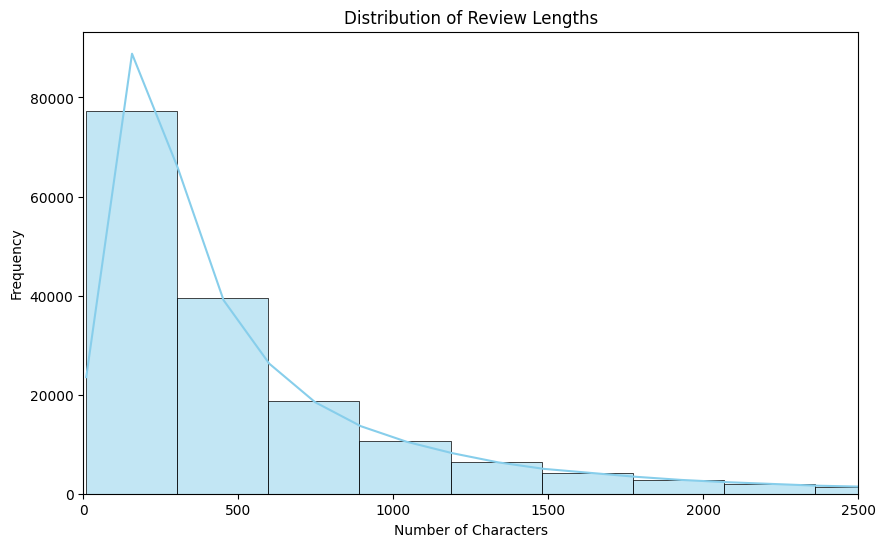

In [0]:
from pyspark.sql.functions import length, col

# Calculate length and sample
df_len = gold_df.withColumn("review_len", length(col("reviewText")))
pdf_len = df_len.select("review_len").sample(False, 0.1, seed=42).toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(pdf_len['review_len'], bins=100, color='skyblue', kde=True)
plt.xlim(0, 2500) # Zoom in on the bulk of reviews
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

/home/spark-064d4186-d93f-4a9c-82be-eb/.ipykernel/2050/command-5782611253566963-1423925574:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='overall', y='review_len', data=pdf_corr, palette='magma')


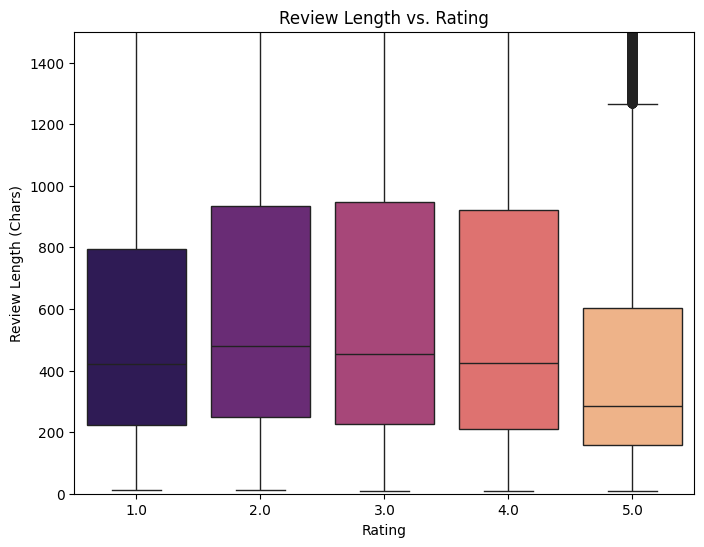

In [0]:
# Sample both columns
pdf_corr = df_len.select("overall", "review_len").sample(False, 0.1, seed=42).toPandas()

plt.figure(figsize=(8, 6))
sns.boxplot(x='overall', y='review_len', data=pdf_corr, palette='magma')
plt.ylim(0, 1500) # Hide extreme outliers for clarity
plt.title('Review Length vs. Rating')
plt.xlabel('Rating')
plt.ylabel('Review Length (Chars)')
plt.show()


In [0]:
sample_n = 300_000    
sample_seed = 42 
df_sampled = gold_df.orderBy("reviewerID").limit(sample_n) 
print("Sampled rows:", df_sampled.count()) 

Sampled rows: 300000


In [0]:
sample_n = 300_000    
sample_seed = 42 

# 1. Calculate the total count to determine the fraction
total_rows = gold_df.count()
fraction = sample_n / total_rows


df_sampled = gold_df.sample(withReplacement=False, fraction=fraction, seed=sample_seed)

df_sampled = df_sampled.limit(sample_n)

print(f"Total Dataset Size: {total_rows}")
print(f"Drift-Resistant Sampled Rows: {df_sampled.count()}")

# Optional: Verify the sample covers the full range of ratings to ensure no bias
display(df_sampled.groupBy("overall").count().orderBy("overall"))

Total Dataset Size: 1687427
Drift-Resistant Sampled Rows: 299813


overall,count
1.0,19320
2.0,14598
3.0,25305
4.0,61332
5.0,179258


In [0]:
sample_n = 300000    
sample_seed = 42 

# 1. Calculate the fraction needed to get roughly 300k rows
total_rows = gold_df.count()
fraction = sample_n / total_rows

# 2. Perform Random Sampling (Drift-Resistant)
# withReplacement=False ensures unique reviews
df_sampled = gold_df.sample(withReplacement=False, fraction=fraction, seed=sample_seed)

# 3. Exact limit to ensure you have exactly 300,000 rows
df_sampled = df_sampled.limit(sample_n)

print(f"Total rows: {total_rows}")
print(f"Sampled rows: {df_sampled.count()}")

Total rows: 1687427
Sampled rows: 299813


In [0]:
 #Check schema matches original 
df_sampled.printSchema() 
# Compare rating distribution with original dataset 
gold_df.groupBy("overall").count().orderBy("overall").show() 
df_sampled.groupBy("overall").count().orderBy("overall").show() 

root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)

+-------+-------+
|overall|  count|
+-------+-------+
|    1.0| 108612|
|    2.0|  82056|
|    3.0| 142106|
|    4.0| 346693|
|    5.0|1007960|
+-------+-------+

+-------+------+
|overall| count|
+-------+------+
|    1.0| 19320|
|    2.0| 14598|
|    3.0| 25305|
|    4.0| 61332|
|    5.0|179258|
+-------+------+



In [0]:
# Ensure your storage account name is defined correctly
storage_account_name = "jana60305219"

# Define the path using an f-string
sampled_gold_path = (
    f"abfss://curated@{storage_account_name}.dfs.core.windows.net/"
    "features_v1_sampled/"
)

# Parentheses allow multi-line commands without backslashes
(df_sampled.write
    .mode("overwrite")
    .parquet(sampled_gold_path))